<a href="https://colab.research.google.com/github/Nicolas-Mazzeo/ELMalditoNINE9/blob/main/CdD_TP1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **TP1 — Análisis Exploratorio de Datos: Twitter y Desastres Naturales**


## **Introducción**

El objetivo de este trabajo es realizar un análisis exploratorio sobre un conjunto
de tweets, con el fin de identificar patrones que permitan distinguir cuáles hacen
referencia a un **desastre real** y cuáles no. Este es el problema de la competencia
de Kaggle [*NLP with Disaster Tweets*](https://www.kaggle.com/competitions/copy-of-nlp-getting-started/data).


### **Composición del dataset**

La pagina Kaggle provee tres archivos:

| Archivo | Uso | Contiene `target` |
|---|---|---|
| `train.csv` | Conjunto de entrenamiento — es el que se utiliza en este análisis | Sí |
| `test.csv` | Conjunto de prueba, pensado para generar predicciones y subirlas a Kaggle | No |
| `sample_submission.csv` | Formato de ejemplo para el envío de predicciones a la competencia | — |

Dado que este TP consiste en un análisis exploratorio (y no en generar predicciones
para la competencia), se trabaja exclusivamente sobre `train.csv`, ya que es el
único archivo que incluye la variable objetivo.


### **Columnas del dataset**

- **`id`**: identificador único de cada tweet.
- **`text`**: texto completo del tweet.
- **`keyword`**: palabra clave asociada al tweet (puede estar vacía).
- **`location`**: ubicación desde la que fue enviado el tweet (puede estar vacía).
- **`target`**: variable a predecir. Vale `1` si el tweet se refiere a un desastre
  real, y `0` en caso contrario. *(Solo presente en `train.csv`)*.

### **Qué se busca predecir**

El problema es de **clasificación binaria**: dado el texto de un tweet (y
opcionalmente su `keyword`/`location`), determinar si describe un desastre real
(`1`) o no (`0`). Este tipo de detección es útil, por ejemplo, para que organismos
de emergencia o medios monitoreen redes sociales en busca de eventos reales en
tiempo real, filtrando el uso figurado o metafórico del lenguaje (ej: "el partido
fue una catástrofe" vs. un tweet reportando un incendio real).


### **Variables derivadas para el análisis**

Además de las columnas originales, se generan variables adicionales para
enriquecer el análisis exploratorio:

- `CantidadDePalabras`: cantidad de palabras del tweet.
- `LongitudTotalCaracteres`: cantidad de caracteres del tweet.
- `LargoPromedioPalabra`: longitud promedio de palabra (`LongitudTotalCaracteres / CantidadDePalabras`).
- `TieneURL`: si el tweet contiene un link.
- `TieneMencion`: si el tweet menciona a otro usuario (`@usuario`).

El análisis se realiza en paralelo con **Pandas** (para consultas más exploratorias
y de manipulación fina) y **PySpark** (simulando un escenario de procesamiento
distribuido), tal como lo pide la consigna del TP1.

# Hipótesis

Planteo que los metadatos del texto reflejan la intención del usuario antes de analizar las palabras:

- **Presencia de URL $\rightarrow$** Noticia real: Un tweet que reporta una
catástrofe suele dar un titular breve y poner un link a la nota completa. Por eso, espero que la presencia de URLs aumente la probabilidad de que el evento sea real (`target = 1`).

- **Presencia de mención $\rightarrow$** Uso figurado: Las menciones a otros usuarios (@) indican interacción casual o quejas del día a día. En este registro, el vocabulario de desastre suele usarse como metáfora o exageración, reduciendo la probabilidad de desastre real (`target = 0`).

## **Pandas**

In [ ]:
import pandas as pd
import pyspark.sql.functions as F
from pyspark.sql import SparkSession
from pyspark.sql.window import Window
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [ ]:
df_pd = pd.read_csv('/content/drive/MyDrive/CN/csv/train.csv')

## Primera consulta

In [ ]:
# Generación de variables derivadas
df_pd['CantidadDePalabras'] = df_pd['text'].apply(lambda x: len(str(x).split()))
df_pd['LongitudTotalCaracteres'] = df_pd['text'].apply(lambda x: len(str(x)))
df_pd['LargoPromedioPalabra'] = df_pd['LongitudTotalCaracteres'] / df_pd['CantidadDePalabras']
df_pd['TieneURL'] = df_pd['text'].str.contains(r'https?://\S+|www\.\S+', regex=True, na=False)
df_pd['TieneMencion'] = df_pd['text'].str.contains(r'@\w+', regex=True, na=False)

In [ ]:
# 1. Balance de clases (value_counts simple)
df_pd['target'].value_counts(normalize=True).mul(100).round(2)

,proportion
target,
0,57.03
1,42.97


El dataset está un poco desbalanceado: el 57.03% de los tweets no refieren a
un desastre real y el 42.97% sí. No es un desbalance fuerte, sigue siendo una métrica razonable, aunque conviene tenerlo presente.

## Segunda consulta :

In [ ]:
# 2. Multi-agregación con nombres
df_pd.groupby('target').agg(
    Cantidad=('id', 'count'),
    Largo_Promedio_De_Caracteres=('LongitudTotalCaracteres', 'mean'),
    Largo_Promedio_De_Palabras=('CantidadDePalabras', 'mean')
).round(2)

,Cantidad,Largo_Promedio_De_Caracteres,Largo_Promedio_De_Palabras
target,,,
0,4342,95.71,14.70
1,3271,108.11,15.17


Los tweets sobre desastres reales son en promedio más largos: 108.11 caracteres
frente a 95.71 (unos 12 caracteres más), y 15.17 palabras frente a 14.70. La
diferencia en palabras es muy poca, pero la de caracteres no. Esto sugiere que los
tweets de desastre real usan palabras más largas —posiblemente vocabulario más
formal o técnico (*evacuation*, *casualties*, *emergency*)— frente al lenguaje más
coloquial y abreviado, ya que seguramente se trate de algo más casual. Se confirma más adelante con las URLs.

## Tercera consulta :

In [ ]:
# 3. Selección de columnas + mean sobre booleanos
df_pd.groupby('target')[['TieneURL', 'TieneMencion']].mean().round(3)

,TieneURL,TieneMencion
target,,
0,0.414,0.309
1,0.664,0.204


Este es de lo más importante y más marca diferencia hasta acá: el 66.4% de los tweets sobre desastres
reales contienen una URL, contra apenas el 41.4% de los que no. La relación se
invierte con las menciones: 20.4% frente a 30.9%.

La interpretación es coherente con el uso real de la app: un tweet que reporta
un desastre suele enlazar a una nota periodística o fuente oficial (comportamiento
informativo, de difusión), mientras que un tweet que usa vocabulario catastrófico en
sentido figurado tiende a ser dirigido a otro tipo de usuarios. Esto explica además la diferencia de longitud vista en la consulta anterior: las URLs suman caracteres sin sumar demasiadas palabras.

## Cuarta consulta :

In [ ]:
# 4. Filtro post-groupby + orden (keywords más asociadas a desastre real)
kw_stats = df_pd.dropna(subset=['keyword']).groupby('keyword').agg(
    Apariciones=('target', 'count'),
    Tasa_De_Desastre=('target', 'mean')
)
kw_stats[kw_stats['Apariciones'] >= 20].sort_values('Tasa_De_Desastre', ascending=False).head(10)

,Apariciones,Tasa_De_Desastre
keyword,,
debris,37,1.000000
derailment,39,1.000000
wreckage,39,1.000000
outbreak,40,0.975000
oil%20spill,38,0.973684
typhoon,38,0.973684
suicide%20bombing,33,0.969697
suicide%20bomber,31,0.967742
bombing,29,0.931034


Filtrando keywords con al menos 20 apariciones (para evitar que casos aislados
distorsionen la tasa), aparecen términos con un poder predictivo altísimo:
*debris*, *derailment* y *wreckage* tienen una tasa de desastre real del 100%, y
*outbreak*, *oil spill* y *typhoon* superan el 97%.

El patrón es claro: son términos técnicos o específicos que difícilmente se usen en
sentido metafórico en una charla cotidiana/normal. Nadie describe un mal día como un
"descarrilamiento". Esto contrasta con palabras de uso figurado frecuente
(*disaster*, *ablaze*, *wreck*), que serán mucho más ambiguas.

Nota técnica: las keywords vienen URL-encoded (`oil%20spill`, `suicide%20bombing`),
donde `%20` representa un espacio.

## Quinta consulta :

In [ ]:
# 5. Agregación + orden por volumen (locations)
df_pd.dropna(subset=['location']).groupby('location').agg(
    Cantidad=('id', 'count'),
    Tasa_De_Desastre=('target', 'mean')
).sort_values('Cantidad', ascending=False).head(15)

,Cantidad,Tasa_De_Desastre
location,,
USA,104,0.644231
New York,71,0.225352
United States,50,0.540000
London,45,0.355556
Canada,29,0.448276
Nigeria,28,0.785714
UK,27,0.592593
"Los Angeles, CA",26,0.307692
India,24,0.833333


El campo `location` es texto libre, sin normalizar, y eso limita su utilidad: conviven
"USA" (104 tweets) y "United States" (50) como entradas distintas, junto con
ciudades, países, regiones y valores genéricos como "Worldwide".

Aun así, la tasa de desastre real varía fuertemente entre ubicaciones: Mumbai (86.4%),
India (83.3%) y Nigeria (78.6%) están muy por encima del promedio del dataset (42.97%),
mientras que New York (22.5%) y Kenya (25.0%) están muy por debajo. Con volúmenes de
20 a 100 tweets por ubicación las conclusiones son frágiles, pero la variación sugiere
que la señal existiría si el campo estuviera normalizado.

### Ejemplificación de las diferentes entradas para un unico pais

In [ ]:
FormasDeUnMismoPais = df_pd['location'].str.contains('America', na=False).sum()
print(f"Cantidad de tuits con 'America' en ubicación: {FormasDeUnMismoPais}")
FormasDeUnMismoPais = df_pd['location'].str.contains('USA', na=False).sum()
print(f"Cantidad de tuits con 'USA' en ubicación: {FormasDeUnMismoPais}")
FormasDeUnMismoPais = df_pd['location'].str.contains('United States', na=False).sum()
print(f"Cantidad de tuits con 'United States'' en ubicación: {FormasDeUnMismoPais}")
FormasDeUnMismoPais = df_pd['location'].str.contains('Estados Unidos', na=False).sum()
print(f"Cantidad de tuits con 'Estados Unidos'' en ubicación: {FormasDeUnMismoPais}")


Cantidad de tuits con 'America' en ubicación: 19
Cantidad de tuits con 'USA' en ubicación: 260
Cantidad de tuits con 'United States'' en ubicación: 62
Cantidad de tuits con 'Estados Unidos'' en ubicación: 1


## **Conclusiones de Pandas**

### **Del análisis con Pandas se desprenden cuatro observaciones principales:**

**1. El dataset está un poco desbalanceado.** Con un 57% de tweets no
relacionados a desastres reales contra un 43% que sí lo están, el desbalance no es grave.

**2. La estructura del tweet aporta señal, independientemente de su contenido.** Sin
mirar una sola palabra del texto, las variables derivadas ya discriminan entre clases:
los tweets de desastre real contienen URL en un 66.4% de los casos contra un 41.4%, y
menciones a otros usuarios en un 20.4% contra un 30.9%. Esta oposición describe dos comportamientos distintos en la plataforma: uno **informativo**, que enlaza a una
fuente externa para difundir un hecho, y otro **conversacional**, dirigido a otros
usuarios, donde el vocabulario catastrófico aparece con frecuencia en sentido figurado.
La diferencia de longitud observada (108 contra 96 caracteres promedio) es consistente
con esta lectura, ya que las URLs suman caracteres sin sumar palabras.

**3. Las keywords tienen un poder predictivo muy desigual, y el motivo es por como se comunica.**
Términos como *debris*, *derailment* o *wreckage* alcanzan el 100% de tasa de desastre
real, mientras que otros son fuertemente ambiguos. La diferencia no es arbitraria: las
keywords más predictivas son palabras más tecnicas y específicas que no tienen uso en una charla cotidiana. La dificultad central del problema no
está entonces en detectar vocabulario catastrófico, sino en **Diferenciar menciones a desastres reales de expresiones figuradas o jerga cotidiana.**, y eso solo puede resolverse mirando el contexto de la oración.

**4. Las columnas auxiliares no tienen la misma utilidad.** `keyword` sirve mucho, aunque requiere limpiarle los caracteres de URL (`%20`). En cambio, `location` es bastante desprolija y tiene muchos datos faltantes. Mezcla ciudades, países y términos como "Worldwide", además de tener el mismo país escrito de varias formas (por ejemplo, `USA` y `United States`). Como hay pocos datos por cada ubicación, no se pueden sacar conclusiones confiables sin hacer una limpieza profunda.

## **Spark**

In [ ]:
pip install pyspark

In [ ]:
from pyspark import SparkContext, SparkConf

# Create a SparkConf object
conf = SparkConf().setAppName("PySpark Colab").setMaster("local[*]")

# Initialize SparkContext
# If a SparkContext is already running, stop it first
if 'sc' in globals() and sc.master.startswith('local'):
    sc.stop()
sc = SparkContext(conf=conf)

print("SparkContext initialized successfully!")
print(f"Spark Application Name: {sc.appName}")
print(f"Spark Master: {sc.master}")

SparkContext initialized successfully!
Spark Application Name: PySpark Colab
Spark Master: local[*]


In [ ]:
from pyspark.sql import SQLContext

In [ ]:
sqlContext = SQLContext(sc)

df = sqlContext.read.csv('/content/drive/MyDrive/CN/csv/train.csv', header=True, inferSchema=True,
                         quote='"', escape='"', multiLine=True)

rdd = df.rdd.cache()
print(rdd.count())

/usr/local/lib/python3.13/dist-packages/pyspark/sql/context.py:112: FutureWarning: Deprecated in 3.0.0. Use SparkSession.builder.getOrCreate() instead.
  warnings.warn(


7613


In [ ]:
import re

## Primera consulta :

In [ ]:
STOPWORDS = {
    'the','a','an','and','or','but','in','on','at','to','for','of','with','is',
    'are','was','were','be','been','being','it','its','this','that','these','those',
    'i','you','he','she','we','they','my','me','your','our','their','his','her',
    'as','by','from','so','if','not','have','has','had','do','does','did','will',
    'would','can','could','should','just','like','all','out','get','got','what',
    'when','who','how','why','where','now','then','more','most','over','after',
    'before','about','into','than','too','very','via','amp','don','via','up','down',
    'via','one','two','new','via','via','let','via','via','still','via','also','there','them'
}

In [ ]:
def tokenizar(texto):
    texto = re.sub(r'https?://\S+|www\.\S+', '', texto.lower())
    texto = re.sub(r'@\w+|#', '', texto)
    return [t for t in re.findall(r'[a-z]+', texto)
            if t not in STOPWORDS and len(t) > 2]

In [ ]:
# 1. Manejo del RDD
frecuencias = rdd \
    .filter(lambda x: x.text is not None and x.target is not None) \
    .flatMap(lambda x: [((x.target, p), 1) for p in tokenizar(x.text)]) \
    .reduceByKey(lambda a, b: a + b)

# 2. Acciones para traer el Top 15 de cada clase
top_1 = frecuencias.filter(lambda x: x[0][0] == 1).takeOrdered(15, key=lambda x: -x[1])
top_0 = frecuencias.filter(lambda x: x[0][0] == 0).takeOrdered(15, key=lambda x: -x[1])

# 3. Muestra de resultados en pantalla
print("TOP 15 PALABRAS: DESASTRE")
for (target, palabra), conteo in top_1:
    print(f"  {palabra:<15} : {conteo}")

print("\nTOP 15 PALABRAS: NO DESASTRE")
for (target, palabra), conteo in top_0:
    print(f"  {palabra:<15} : {conteo}")

TOP 15 PALABRAS: DESASTRE
  fire            : 182
  news            : 146
  disaster        : 121
  california      : 115
  suicide         : 112
  police          : 109
  people          : 105
  killed          : 95
  hiroshima       : 94
  storm           : 89
  crash           : 85
  fires           : 85
  families        : 81
  train           : 79
  emergency       : 77

TOP 15 PALABRAS: NO DESASTRE
  body            : 116
  video           : 96
  people          : 94
  love            : 91
  day             : 86
  time            : 86
  know            : 86
  back            : 85
  full            : 84
  see             : 82
  emergency       : 81
  going           : 76
  fire            : 72
  some            : 71
  want            : 67


**Clase "desastre real"**: Usan sustantivos concretos de evento (*fire*, *disaster*,
*storm*, *crash*, *emergency*), instituciones (*police*), consecuencias
(*killed*) y sobre todo, **referencias a eventos específicos y
verificables**: *california* (incendios forestales), *hiroshima* (aniversario del
bombardeo), *suicide*, *train*. La presencia de `news`  confirma el
análisis de URLs: son tweets que reportan o citan una fuente.

**Clase "no desastre"**: Es mucho más genérico *love*, *day*,
*time*, *know*, *see*, *going*, *back*, *video*. No hay entidades nombradas ni
referencias a hechos concretos. Es lenguaje de experiencia personal, no de reporte.

**El hallazgo central:** Tres palabras aparecen en ambos
tops, y son las que explican la dificultad real del problema:

| Palabra | Desastre | No desastre |
|---|---|---|
| `fire` | 182 | 72 |
| `emergency` | 77 | 81 |
| `people` | 105 | 94 |

`emergency` es aparece casi la misma
cantidad de veces en un reporte de emergencia real que en usos figurados
("emergencia" para describir cualquier contratiempo). Lo mismo ocurre con `people`.
Esto confirma la idea planteada en las conclusiones de Pandas:
**la presencia de vocabulario catastrófico no alcanza para clasificar**, porque parte
de ese vocabulario se usa en ambos registros.

`fire` es el caso intermedio: ya sus
apariciones corresponden a usos no relacionados a incendios (*fire* como verbo,
expresiones).

**Nota**: *fire* (182) y *fires* (85) se contabilizan como
distintos por ausencia de unificación.
Seguramente lo mismo ocurre con palabras similares, pero por ahora solo resalta esta.

## Segunda consulta :

In [ ]:
locations = rdd \
    .filter(lambda x: x.location is not None and x.target is not None) \
    .map(lambda x: (x.location.strip(), (x.target, 1))) \
    .reduceByKey(lambda a, b: (a[0] + b[0], a[1] + b[1])) \
    .filter(lambda x: x[1][1] >= 15) \
    .map(lambda x: (x[0], x[1][1], round(x[1][0] / x[1][1], 3))) \
    .takeOrdered(15, key=lambda x: -x[1])

for loc, total, tasa in locations:
    print(f"  {loc:<25} {total:<5} {tasa:.1%}")

  USA                       105   63.8%
  New York                  73    23.3%
  United States             50    54.0%
  London                    46    34.8%
  Nigeria                   32    81.2%
  Canada                    30    43.3%
  UK                        27    59.3%
  Los Angeles, CA           26    30.8%
  India                     24    83.3%
  Mumbai                    22    86.4%
  Washington, DC            21    71.4%
  California                20    45.0%
  Kenya                     20    25.0%
  Australia                 19    52.6%
  Worldwide                 19    63.2%


Ordenando por volumen, la primera lectura es de calidad de datos: `USA` (105) y
`United States` (50) ocupan puestos separados en el mismo ranking, igual que `London`
(46) y `UK` (27), o `Los Angeles, CA` (26) y `California` (20). El campo no está
normalizado, así que el ranking mide *cómo escribe la gente su ubicación*, no dónde
está. Aparece incluso `Worldwide` (19), que no es una ubicación.

Un detalle: al aplicar `.strip()` sobre la ubicación, los conteos
subieron levemente respecto del análisis en Pandas (`USA` pasó de 104 a 105,
`New York` de 71 a 73). Entradas idénticas con espacios sobrantes se contaban como
categorías distintas.

La tasa de desastre real varía mucho más de lo que explicaría el
azar. Muy por encima del promedio del dataset (42,97%) aparecen `Mumbai` (86,4%),
`India` (83,3%) y `Nigeria` (81,2%); muy por debajo, `New York` (23,3%), `Kenya`
(25,0%) y `Los Angeles, CA` (30,8%). La hipótesis más sencilla es que no es geográfica sino
de composición de usuarios: las ubicaciones con tasas altas concentran cuentas de
medios y agregadores de noticias, mientras que las grandes ciudades occidentales
concentran usuarios individuales tuiteando de forma casual. Sostenerlo
requeriría inspeccionar las cuentas, dato que el dataset no incluye.

## Tercera consulta :

In [ ]:
keywords = rdd \
    .filter(lambda x: x.keyword is not None and x.target is not None) \
    .map(lambda x: (x.keyword.replace('%20', ' '), (x.target, 1))) \
    .reduceByKey(lambda a, b: (a[0] + b[0], a[1] + b[1])) \
    .filter(lambda x: x[1][1] >= 20) \
    .map(lambda x: (x[0], abs(x[1][0] / x[1][1] - 0.5)))

# reduce: comparación de a dos, sin ordenamiento global
mas_ambigua = keywords.reduce(lambda a, b: a if a[1] < b[1] else b)
print(f"Keyword más ambigua: {mas_ambigua[0]} (desvío de 0.5: {mas_ambigua[1]:.4f})")

Keyword más ambigua: bombed (desvío de 0.5: 0.0000)


El resultado es notable por lo extremo: `bombed` tiene un desvío de 0.0000 respecto
del 50%, es decir que *exactamente la mitad* de sus apariciones corresponden a
desastres reales y la otra mitad no. Es el caso perfecto de ambigüedad léxica.

El motivo es "cultural": en inglés coloquial *bombed* se usa habitualmente para
"fracasar" (un examen, un show, una presentación), un sentido
completamente desconectado del literal. Para un clasificador basado en presencia de
palabras, esta keyword no aporta absolutamente nada.

Esto cierra lo que venimos siguiendo. En un extremo están las
keywords tecnicas (`debris`, `derailment`, `wreckage`, con tasa 100%); en el otro,
`bombed`, con poder predictivo nulo. La dificultad del problema no está distribuida
de manera uniforme sobre el vocabulario, sino concentrada en los términos con doble
sentido establecido.

## Cuarta consulta :

In [ ]:
URL_RE = re.compile(r'https?://\S+|www\.\S+')

cruce = rdd \
    .filter(lambda x: x.text is not None and x.target is not None) \
    .map(lambda x: ((x.target, bool(URL_RE.search(x.text))), 1)) \
    .reduceByKey(lambda a, b: a + b) \
    .collect()   # solo 4 claves posibles, el collect es seguro

for (target, tiene_url), cant in sorted(cruce):
    print(f"  target={target}  URL={tiene_url}  →  {cant}")

  target=0  URL=False  →  2543
  target=0  URL=True  →  1799
  target=1  URL=False  →  1099
  target=1  URL=True  →  2172


La tabla de contingencia completa:

| | Sin URL | Con URL | Total | % con URL |
|---|---|---|---|---|
| No desastre | 2543 | 1799 | 4342 | 41,4% |
| Desastre real | 1099 | 2172 | 3271 | 66,4% |

Los totales por clase (4342 y 3271) coinciden exactamente con los obtenidos en Pandas,
lo que valida que el parseo del CSV en Spark fue correcto — un punto no trivial, dado
que los tuits contienen comas y saltos de línea dentro del campo `text`.

El cruce confirma el hallazgo principal del análisis exploratorio: un
tweet sobre un desastre real tiene 1,6 veces más probabilidad de incluir un enlace.
Visto al revés, entre los tuits **sin** URL solo el 30,2% corresponde a desastres
reales, mientras que entre los que **sí** la tienen la proporción sube al 54,7%. La
sola presencia de un enlace desplaza la probabilidad casi 25 puntos porcentuales.

Es un dato relevante de cara al modelado: `TieneURL` es una feature de una sola línea
de código que aporta señal comparable a buena parte del vocabulario, y no requiere
vectorizar el texto.

# Visualizaciónes

# Visualización 1 — Espectro de ambigüedad de keywords

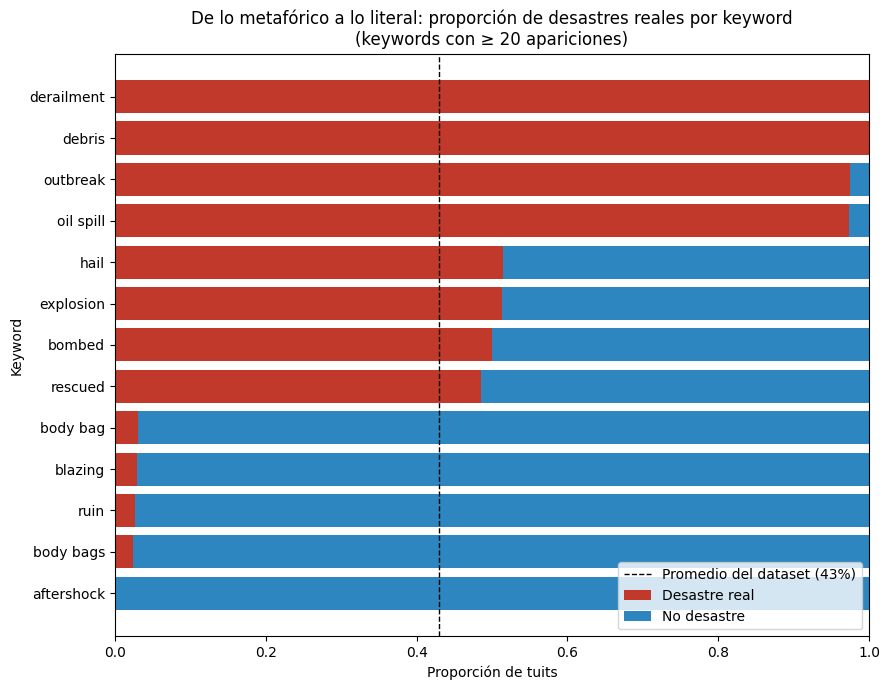

In [ ]:
kw = df_pd.dropna(subset=['keyword']).copy()
kw['keyword'] = kw['keyword'].str.replace('%20', ' ')

kw_df = kw.groupby(['keyword', 'target']).size().unstack(fill_value=0)
kw_df['total'] = kw_df[0] + kw_df[1]
kw_df['tasa'] = kw_df[1] / kw_df['total']
kw_f = kw_df[kw_df['total'] >= 20]

ambiguas = kw_f.iloc[(kw_f['tasa'] - 0.5).abs().argsort()[:5]]
vis1 = pd.concat([kw_f.nsmallest(5, 'tasa'), ambiguas, kw_f.nlargest(5, 'tasa')]) \
         .drop_duplicates().sort_values('tasa')

fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(vis1.index, vis1['tasa'], color='#C0392B', label='Desastre real')
ax.barh(vis1.index, 1 - vis1['tasa'], left=vis1['tasa'], color='#2E86C1', label='No desastre')
ax.axvline(df_pd['target'].mean(), color='black', linestyle='--', linewidth=1,
           label=f"Promedio del dataset ({df_pd['target'].mean():.0%})")
ax.set_xlabel('Proporción de tuits')
ax.set_ylabel('Keyword')
ax.set_title('De lo metafórico a lo literal: proporción de desastres reales por keyword\n(keywords con ≥ 20 apariciones)')
ax.set_xlim(0, 1)
ax.legend(loc='lower right')
plt.tight_layout(); plt.show()

Muestra cómo varía la tasa de desastre real según la palabra clave: en los extremos están los términos técnicos (debris, derailment) con 100% de precisión, mientras que en el centro aparecen términos con doble sentido (bombed), donde la probabilidad cae al 50% y el poder predictivo es nulo.

# Visualización 2 — Longitud por clase (boxplot)

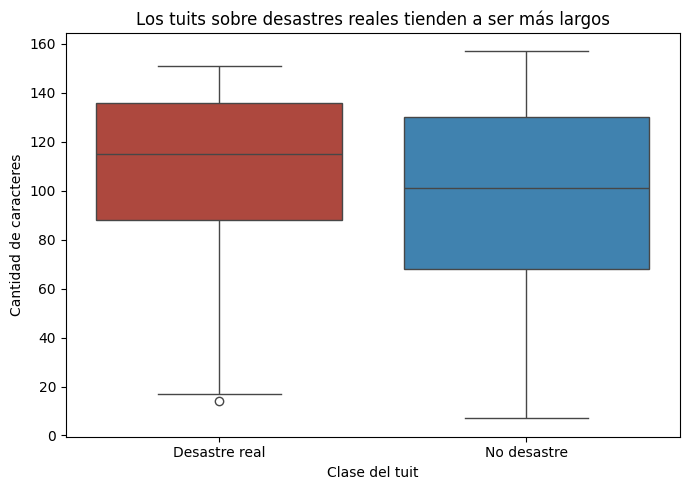

In [ ]:
vis2 = df_pd[['target', 'LongitudTotalCaracteres']].copy()
vis2['clase'] = vis2['target'].map({0: 'No desastre', 1: 'Desastre real'})

plt.figure(figsize=(7, 5))
sns.boxplot(data=vis2, x='clase', y='LongitudTotalCaracteres', hue='clase',
            palette={'No desastre': '#2E86C1', 'Desastre real': '#C0392B'}, legend=False)
plt.xlabel('Clase del tuit')
plt.ylabel('Cantidad de caracteres')
plt.title('Los tuits sobre desastres reales tienden a ser más largos')
plt.tight_layout(); plt.show()

Los tuits sobre desastres reales tienen una mediana de caracteres notablemente mayor que los no desastres. Esta diferencia responde principalmente a la presencia de enlaces externos (URLs), que extienden la longitud del texto sin incrementar en la misma proporción la cantidad de palabras.

# Visualización 3 — Heatmap de correlaciones

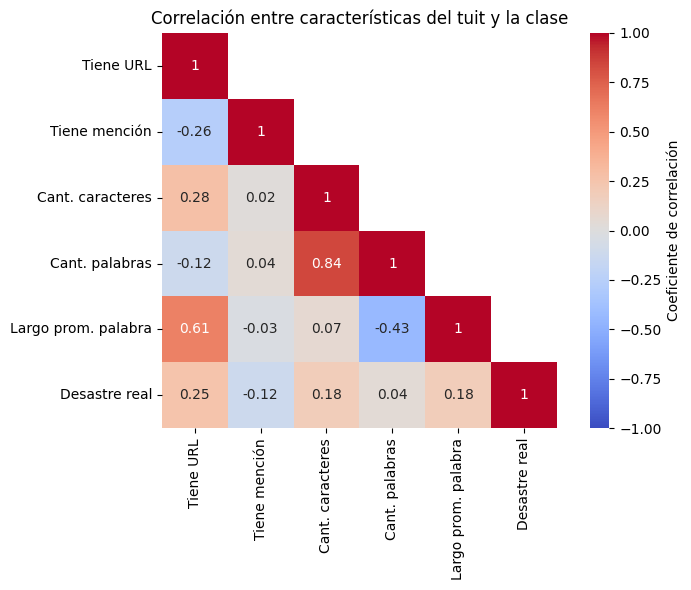

In [ ]:
cols = {
    'TieneURL': 'Tiene URL',
    'TieneMencion': 'Tiene mención',
    'LongitudTotalCaracteres': 'Cant. caracteres',
    'CantidadDePalabras': 'Cant. palabras',
    'LargoPromedioPalabra': 'Largo prom. palabra',
    'target': 'Desastre real'
}
vis3 = df_pd[list(cols)].astype(float).rename(columns=cols).corr().round(2)
mask = np.triu(np.ones_like(vis3, dtype=bool), k=1)

plt.figure(figsize=(8, 6))
sns.heatmap(vis3, mask=mask, annot=True, cmap='coolwarm', vmin=-1, vmax=1,
            square=True, cbar_kws={'label': 'Coeficiente de correlación'})
plt.title('Correlación entre características del tuit y la clase')
plt.tight_layout(); plt.show()

Comprueba numéricamente la hipótesis estructural: TieneURL y LongitudTotalCaracteres muestran la mayor correlación positiva con la variable objetivo (`target = 1`), mientras que TieneMencion presenta correlación negativa, confirmando su uso ligado al tono conversacional y figurado.

# Visualización 4 — Top 10 Hashtags en desastres reales

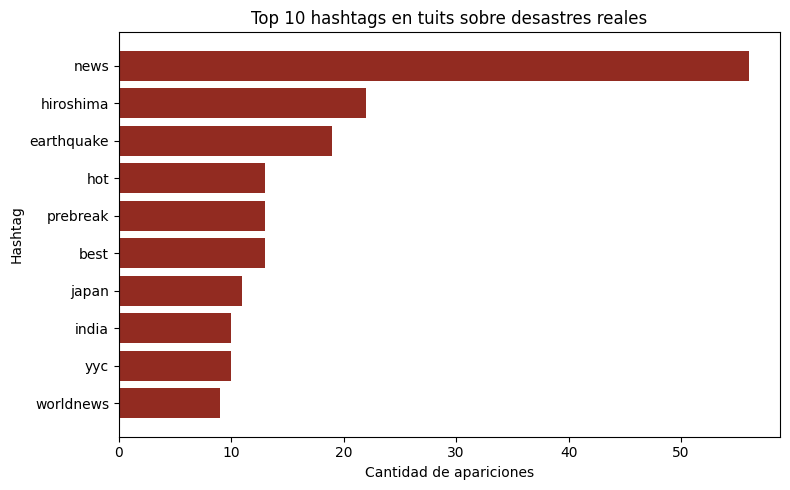

In [ ]:
vis4 = (df_pd[df_pd['target'] == 1]['text']
        .str.lower()
        .str.findall(r'#(\w+)')
        .explode()
        .dropna()
        .value_counts()
        .head(10)
        .sort_values())

plt.figure(figsize=(8, 5))
plt.barh(vis4.index, vis4.values, color='#922B21')
plt.xlabel('Cantidad de apariciones')
plt.ylabel('Hashtag')
plt.title('Top 10 hashtags en tuits sobre desastres reales')
plt.tight_layout(); plt.show()

Refleja que los hashtags en reportes reales se concentran en noticias (news), coberturas meteorológicas/regionales o pedidos de auxilio. Confirma el uso de la plataforma como canal de difusión e información pública ante hechos concretos.

# **Visualizaciones Extra**

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

CompTw = mpimg.imread('/content/drive/MyDrive/CN/img/CompTw.png')
ContrasteAblaze = mpimg.imread('/content/drive/MyDrive/CN/img/ContrasteAblaze.png')

### **Datos conseguidos vistos desde un tweet :**

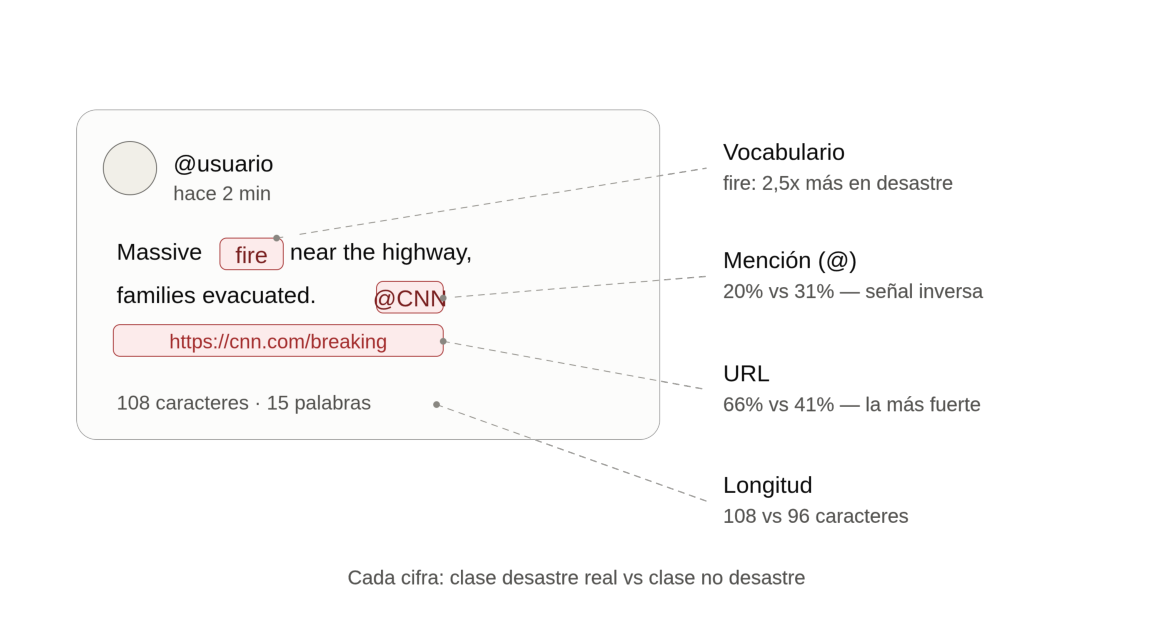

In [ ]:
plt.figure(figsize=(15, 8))
plt.imshow(CompTw)
plt.axis('off')  # Oculta los ejes numéricos

plt.show()

### **Misma palabra, diferente contexto :**

In [ ]:
candidato = df_pd[(df_pd['target'] == 1) &
                  (df_pd['TieneURL']) &
                  (df_pd['TieneMencion'])].sort_values('LongitudTotalCaracteres')
candidato[['text', 'keyword', 'LongitudTotalCaracteres']].head(5)

,text,keyword,LongitudTotalCaracteres
6811,@CSAresu American Tragedy http://t.co/SDmrzG...,tragedy,50
5943,I JUST SCREAMED @toddyrockstar http://t.co/JDt...,screamed,53
31,@bbcmtd Wholesale Markets ablaze http://t.co/l...,ablaze,55
2880,Thought it was a drought @_ASHJ? http://t.co/V...,drought,55
6894,@disneyIrh so traumatised im ???? http://t.co/...,traumatised,56


In [ ]:
df_pd.loc[[31], ['text', 'keyword', 'LongitudTotalCaracteres']]

,text,keyword,LongitudTotalCaracteres
31,@bbcmtd Wholesale Markets ablaze http://t.co/l...,ablaze,55


In [ ]:
df_pd[(df_pd['keyword'] == 'ablaze') & (df_pd['target'] == 0)][['text', 'LongitudTotalCaracteres']].head(10)

,text,LongitudTotalCaracteres
32,We always try to bring the heavy. #metal #RT h...,67
34,Crying out for more! Set me ablaze,34
35,On plus side LOOK AT THE SKY LAST NIGHT IT WAS...,76
36,@PhDSquares #mufc they've built so much hype a...,122
39,Ablaze for you Lord :D,22
40,Check these out: http://t.co/rOI2NSmEJJ http:/...,114
41,on the outside you're ablaze and alive\nbut yo...,61
42,Had an awesome time visiting the CFC head offi...,120
43,SOOOO PUMPED FOR ABLAZE ???? @southridgelife,44
44,I wanted to set Chicago ablaze with my preachi...,92


In [ ]:
df_pd.loc[[36], ['text', 'keyword', 'LongitudTotalCaracteres']]

,text,keyword,LongitudTotalCaracteres
36,@PhDSquares #mufc they've built so much hype a...,ablaze,122


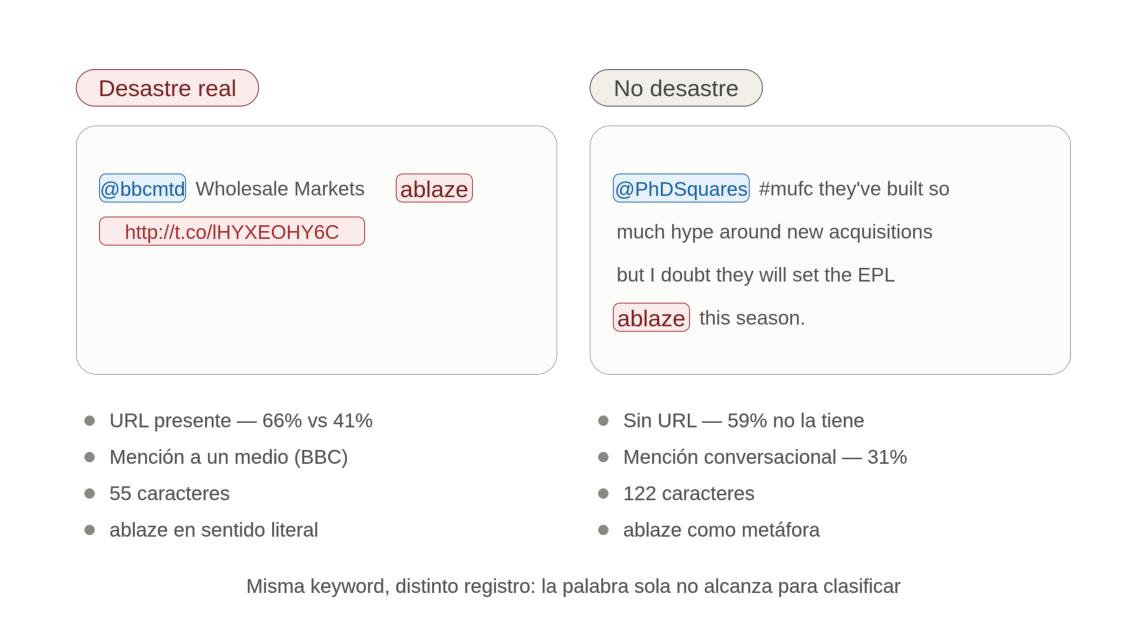

In [ ]:
plt.figure(figsize=(15, 8))

plt.imshow(ContrasteAblaze)
plt.axis('off')  # Oculta los ejes numéricos

plt.show()

Expone el problema de la ambigüedad en el uso: la palabra ablaze aparece tanto para reportar un incendio físico real (target = 1) como para un sentido figurado cotidiano (target = 0). Demuestra visualmente por qué la presencia aislada de una keyword no alcanza para clasificar sin evaluar el contexto sintáctico de la oración.

---

# **Conclusiones finales**

El análisis exploratorio realizado con Pandas, PySpark (RDDs) y las visualizaciones confirma la hipótesis inicial sobre cómo la estructura del tuit refleja la intención del emisor:

**Confirmación de la hipótesis estructural:** Los metadatos del texto capturan el comportamiento del usuario antes de procesar semánticamente el contenido:

* **Presencia de URL $\rightarrow$ Registro informativo:** Se comprueba que los tuits que reportan eventos reales suelen funcionar como titulares para derivar tráfico a fuentes externas o coberturas completas. Tener un link desplaza la probabilidad de desastre real del 30,2% al 54,7% (el 66,4% de los tuits de desastres reales contienen URL frente al 41,4% de los que no).
* **Presencia de mención $\rightarrow$ Registro conversacional / figurado:** Las menciones a otros usuarios (`@`) operan en sentido inverso (20,4% en desastres reales frente a 30,9% en no desastres). Indican interacción cotidiana o comentarios casuales donde el léxico catastrófico se utiliza de forma hiperbólica o metafórica.

Son dos *features* de muy bajo costo computacional que aportan señal predictiva inmediata sin requerir depurar los datos.

**La dificultad real es la doble función de las palabras.** Este es el desafío central del problema. Las keywords van desde términos técnicos como `debris`, `derailment` y `wreckage` (100% desastre real) hasta palabras de uso coloquial como `bombed` (exactamente 50%, poder predictivo nulo). El conteo de palabras en Spark lo confirmó: términos como `emergency` aparecen 77 veces en desastres y 81 en no desastres, demostrando que la presencia aislada de vocabulario de catástrofe no alcanza para clasificar sin evaluar el contexto de la oración.

**Limitaciones y trabajo pendiente.**

* El campo `location` requiere una normalización profunda (unificar variantes como `USA` y `United States`) antes de aportar valor al modelo.
* La limpieza de texto en el preprocesamiento debe incluir remoción de URL-encoding en keywords (`%20` $\rightarrow$ espacio) y unificar variantes de las mismas palabras como `fire` (182) y `fires` (85).